# Performance of vector summation

We provide a set of functions for benchmarking performance of summation with
* Arbitrary precision MPFR
* Stagnation detection
* Regular floating-point addition

Our tool `StagnationDetection.jl` includes the function `lrsum`, which explicitly performs left-to-right recursive summation on a vector. This ensures that the exact same summation algorithm is applied in all cases.

We use `BenchmarkTools: @benchmark` to measure performance of vector summation for a range of summation lengths in the magnitude of $10^6$. 

In [1]:
using Random
using StagnationDetection
using BenchmarkTools
using Plots

import Statistics: mean

[ Info: Precompiling IJuliaExt [6e0e26ac-fb43-584e-b323-fdbabcf95812] (caches not reused: 1 for different dependency version already loaded, 1 for dependency source file not found)
Precompiling packages...
   1.5 s  ✓ Plots → IJuliaExt
  1 dependency successfully precompiled in 2 seconds. 173 already precompiled.


In [ ]:
## functions for execution of @benchmark

mpfrsumbench(n::Int, p::Int) = @benchmark begin
    xtrue = lrsum(X_big)
    (xtrue - fp64sum)/xtrue
end setup = begin
    setprecision(BigFloat, $p)
    X = reinterpret.(Float64, rand(UInt64, $n))
    fp64sum = lrsum(X)
    X_big = BigFloat.(X)
end

sdsumbench(n::Int) = @benchmark begin
    lrsum(S) 
end setup = begin
    X = reinterpret.(Float64, rand(UInt64, $n))
    S = FloatSD.(X)
end

normalsumbench(n::Int) = @benchmark begin
    lrsum(X)
end setup = begin
    X = reinterpret.(Float64, rand(UInt64, $n))
end

normalsumbench (generic function with 1 method)

In [3]:
## run benchmarks
# times is recorded in nanoseconds, convert to milliseconds

N::Vector{Int} = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]

MPFR = zeros(Float64, 5)
SD = zeros(Float64, 5)
LR = zeros(Float64, 5)

for i in 1:5
    n = N[i]
    p = 128

    b1 = mpfrsumbench(n, p)
    MPFR[i] = mean(b1.times) / 1e6

    b2 = sdsumbench(n)
    SD[i] = mean(b2.times) / 1e6

    b3 = normalsumbench(n)
    LR[i] = mean(b3.times) / 1e6

end

In [4]:
# results as csv
println("n, mp128, stag, fp64")
for i in 1:5
    println(string(N[i]), ", ", string(MPFR[i]), ", ", string(SD[i]), ", ", string(LR[i]))
end

n, mp128, stag, fp64
1000000, 57.451948951219514, 6.587964095238095, 0.5166244353535353
2000000, 114.68372121052631, 13.512275725490195, 1.0880964598825833
3000000, 216.11242546153846, 20.07372894117647, 1.4872780960698688
4000000, 321.3500146666667, 27.024006875, 1.9952124761904761
5000000, 351.70460071428573, 32.92537497916667, 2.606033327868852


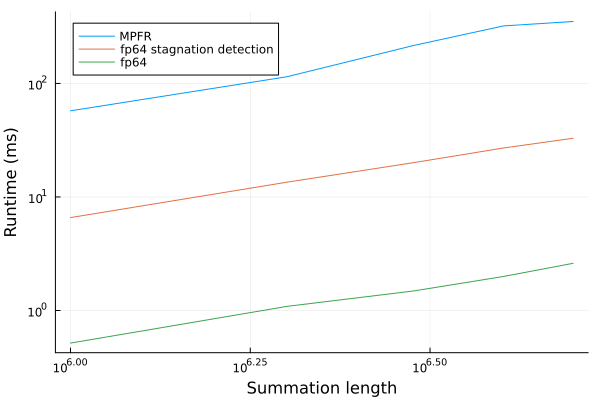

In [5]:
# graph of results
pl = plot(N, [MPFR SD LR], xlabel = "Summation length", ylabel = "Runtime (ms)", xscale = :log10, yscale = :log10, label = ["MPFR" "fp64 stagnation detection" "fp64"])